# Notebook For Figure S8 Method Paper

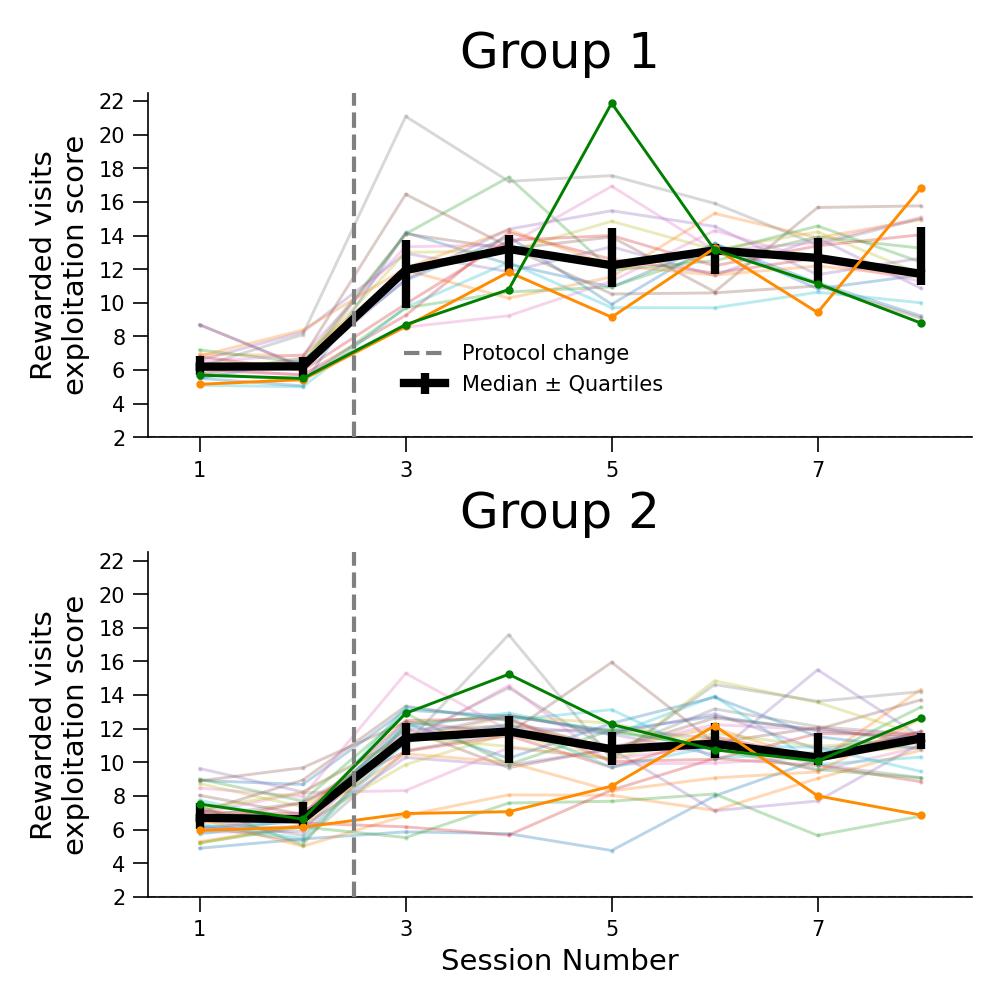

In [13]:
from IPython.display import display
from PIL import Image

# Load and display the image
img = Image.open("FigureS15.png")
display(img)


# 1. Importing necessary libraries and general functions  

In [2]:
import os
from processing_TowerCoordinates import *
from processing_session_trajectory import *
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
import numpy as np
import pickle
import similaritymeasures as sm
from scipy.stats import permutation_test

plt.style.use('paper.mplstyle')



In [3]:
plotintermediatesteps = False 

# 2. Select mice that will be analysed in the figure
### Define the data_folder where your MOU* folders are, enter the list of mice (MOU* folders), define the sessions that will be used for each animals

In [4]:
# defining data folder path and mice list

# path_to_data_folder is the path of the folder where you store the folders of your different mice.

path_to_data_folder_1='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/Group1Data/'
path_to_data_folder_2='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/Group2Data/'
# path_to_data_folder_1 = '/home/tom/Code/tower_foraging_park_data/Group1Data'
# path_to_data_folder_2 = '/home/tom/Code/tower_foraging_park_data/Group2Data'

# path_to_data_folder_1='/home/david/MyLocalData/4TowersTask_MethodPaper/Group1Data'
# path_to_data_folder_2='/home/david/MyLocalData/4TowersTask_MethodPaper/Group2Data'

# path_to_data_folder = '/Users/davidrobbe/Documents/Science/Data/ForagingMice/AurelienData/'

# Analysing the entire group of mice
mice_to_analyse_1 = [
    "MOUEml1_5", "MOUEml1_8", "MOUEml1_11", "MOUEml1_12", "MOUEml1_13", "MOUEml1_15", "MOUEml1_18", "MOUEml1_20",
    "MOURhoA_2", "MOURhoA_5", "MOURhoA_6", "MOURhoA_8", "MOURhoA_9", "MOURhoA_12", "MOURhoA_14",
    "MOUB6NN_4", "MOUB6NN_6", "MOUB6NN_13", "MOUB6NN_15"
]

mice_to_analyse_2 = ['MOU3974','MOU3975', 'MOU3987', 'MOU3988', 'MOU3991', 'MOU3992', 'MOU4551', 'MOU4552', 'MOU4560', 'MOU4561', 'MOU4562',
                   'MOU4563', 'MOU4623', 'MOU4964', 'MOU4965', 'MOU4986', 'MOU4987', 'MOU4988', 'MOU4993', 'MOU5007', 'MOU5008','MOU5130',
                   'MOU5131', 'MOU5136', 'MOU5140', 'MOU5142', 'MOU5143', 'MOU5144', 'MOU5145', 'MOU5148', 'MOU5149', 'MOU5158']


# Verify that all folders in mice_to_analyse_1 and mice_to_analyse_2 are present in path_to_data_folder
missing_folders = [mouse for mouse in mice_to_analyse_1 if not os.path.isdir(os.path.join(path_to_data_folder_1, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders from group 1 are present in data folder.")

missing_folders = [mouse for mouse in mice_to_analyse_2 if not os.path.isdir(os.path.join(path_to_data_folder_2, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders from group 2 are present in data folder.")


# Print the number of mice, the list of mice
print(f'{len(mice_to_analyse_1)+len(mice_to_analyse_2)} {"mice" if len(mice_to_analyse_1)+len(mice_to_analyse_2) > 1 else "mouse"} will be analysed.')

# Select the number of sessions that will be analysed for each mice knowing the analysis starts with the first session (familiarisation)
first_and_last_session_indexes_1 = [18,26]
first_and_last_session_indexes_2 = [32,40]

# Select the offset to apply to the number of the sessions when plotting. By default, it is equal to the number of the first session.
# It resulsts in sessions being named respectively to their actual positions in the data set. TODO: Should reformulate this 
session_index_offset_1 = first_and_last_session_indexes_1[0]
session_index_offset_2 = first_and_last_session_indexes_2[0]

# Setting the seed for random processes used in statistics
seed = 27
np.random.seed(seed)

All mice folders from group 1 are present in data folder.
All mice folders from group 2 are present in data folder.
51 mice will be analysed.


# 3. Chosing illustration mice and sessions  

In [5]:
# Chose the 2 mice that are highlighted in statistics across figures
illustration_mice_1 = ['MOUEml1_8', 'MOUEml1_5']
illustration_mice_2 = ['MOU3974', 'MOU4561']

# Chose the color with which the illustration mice will highlighted with
illustration_colors = ['darkorange', 'green']

# Set the limits of the x-axis on the statistics plots
xlim_stats_1 = [0.5,8.5] #[first_and_last_session_indexes_1[0]+0.5,first_and_last_session_indexes_1[1]+0.5]
xlim_stats_2 = [0.5,8.5] #[first_and_last_session_indexes_2[0]+0.5,first_and_last_session_indexes_2[1]+0.5]


# 4. General functions

In [6]:
def force_aspect(ax, ratio=1):
    """
    Force the aspect ratio of the given axis (ax) to a specific ratio.
    The ratio parameter allows scaling of the aspect ratio. Default is 1.
    
    Arguments:
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        ratio (float, optional): Ratio of the figure's dimensions
    
    """
    
    ratio = 1.0  # Set ratio to 1.0, making the aspect ratio 1:1 by default
    
    # Get the current limits of the x and y axes
    x_left, x_right = ax.get_xlim()  # Get the left and right x-axis limits
    y_low, y_high = ax.get_ylim()    # Get the lower and upper y-axis limits
    
    # Calculate the new aspect ratio and set it
    # The formula is the absolute ratio of the width and height, adjusted by the given ratio
    ax.set_aspect(abs((x_right - x_left) / (y_low - y_high)) * ratio)

def cm2inch(value):

    """
    Converts centimeters to inches for figure size.

    Arguments:
        value (float): value to convert in cm 

    """

    return value/2.54

def filter_qts(qts):

    """
    Filter out QTs with length above threshold and during which more than 1 switch occured.

    Arguments:
        qts (list): list of QTs (in the original format from the pickle)

    return:
        (list): list of filtered QTs
    """

    filtered_qts = []

    
    for qt in qts:

        # Skip current QT if there is more than 1 switches
        if qt[3]['num_trapezeswitch']!=1:
            
            continue
        
        # Skip current QT if it is longer than a threshold length (30 cm)
        if qt[4]['epoch_distance']>30:

            continue

        # Keep current QT if it did not check the removal conditions
        filtered_qts.append(qt)

    return filtered_qts

def count_qts(qts):

    total_qts = len(qts)
    cw_qts = 0
    rewarded_qts = 0

    for qt in qts:

        if qt[3]['direction']=='CW':

            cw_qts += 1

        if qt[3]['Rewarded']:

            rewarded_qts += 1

    return total_qts, cw_qts, rewarded_qts

def compute_average_direction(points):

    """
    Compute the average direction of a trajectory portion, assuming the coordinates are in chronological order.

    Arguments:
        points (2D numpy.array): Trajectory of which the average direction will be computed

    Outputs:
        avg_diff (1D numpy.array): vector pointing to the average direction
        angle (float): angle of the vector with the x-axis 
    """
    
    diffs = np.diff(points, axis=0)
    avg_diff = np.mean(diffs, axis=0)
    angle = np.arctan2(avg_diff[1], avg_diff[0])
    return avg_diff, angle

def finding_mouse_rewarded_direction(folder_path_mouse_to_process, session_index):
    
    """
    Determines the rewarded direction for the session corresponding to the input index of a given mouse. 
    This index is relative to the session position in the series of analysed sessions.
    This input index can have an offset. This is usefull if the sessions series analysed does not start with the first session. 
    
    Arguments:
        folder_path_mouse_to_process (str): Path to the folder containing mouse sessions folders.
        session_index (int): Index of the session that will be used to define the rewarded direction

    Returns:
        str: 'CW' (Clockwise) if the rewarded direction is 270 degrees,
             'CCW' (Counterclockwise) if the rewarded direction is 90 degrees,
             numpy.nan if reward delivery is not allowed 
             None if an error occurs or if both directions are rewarded.
    """
    
    # Get all session folders that start with 'MOU' and sort them
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    # Load data from the last session
    session_traj_df, session_turns_df, session_param_df = load_data(folder_path_mouse_to_process, sessions_to_process[session_index])

    # Extract rewarded direction in degrees
    rewarded_direction_degrees = session_param_df["potentialRewardedDirections"][0]

    # Check if reward delivery is allowed
    if session_param_df["allowRewardDelivery"][0]:

        # Determine the rewarded direction based on the extracted value
        if rewarded_direction_degrees == '[270]':
            rewarded_direction = 'CW'  # Clockwise

        elif rewarded_direction_degrees == '[90]':
            rewarded_direction = 'CCW'  # Counterclockwise
        
        elif rewarded_direction_degrees == '[90, 270]':
            rewarded_direction = 'both'  # Clockwise and Counterclockwise

        # Returns None if the rewarded direction entry in session_param_df is not recognized
        else:
            print('ERROR: Unexpected rewarded direction value:', rewarded_direction_degrees)
            return None  # Explicitly return None to indicate failure
    
    else:

        # Rewarded direction is set to X if reward delivery os not allowed
        rewarded_direction = 'X'

    return rewarded_direction


def plot_learning_curves(mouse_metric_persession, ax, mice_list=None, mice_to_highlight=[], mice_to_highlight_labels=[None,None],
                         highlight_colors = ["darkorange", "green"], show_individual_mice=True, median_color='black',
                         show_xlabel=True, ylabel='', main_line_label=None, tick_interval=1, index_offset=0, xlim=[None,None],
                         ylim=None, show_legend=True, legend_loc=(0.05, 0.9)):
    
    """
    Plots a given metric across sessions for multiple mice (also called a learning curves).

    Arguments:
        mouse_metric_persession (dict): Dictionary where keys are mouse IDs and values are lists of (session_index, value) lists.
        mice_list (list, optional): List of mice to include in the plot. Defaults to all mice in the mouse_metric_persession.
        mice_to_highlight (list, optional): List of up to two mice IDs to highlight with distinct colors.
        mice_to_highlight_labels (list, optional): List of the label of the mice to highlight.
        show_individual_mice (bool): If true, plot a line for each individual mouse.
        ax (matplotlib.axes.Axes): Axes object for plotting.
        show_xlabel (bool, optional): Whether to display the x-axis label. Defaults to True.
        ylabel (str, optional): Label for the y-axis.
        main_line_label (str, optional): Label of the median and quartiles range.
        tick_interval (int, optional): Interval for x-axis tick marks. Defaults to 1.
        index_offset (int, optional): Offset to apply to the numbers in the x axis. Use it if you want to the first sessions to be named '1'.
        xlim (tuple, optional): Tuple specifying x-axis limits. Defaults to None.
        ylim (tuple, optional): Tuple specifying y-axis limits. Defaults to None.
        show_legend (bool, optional): Whether to show the legend. Defaults to True.
        legend_loc (tupple, optional): Location of the legend.
    """

    # If no mice are specified, use all available mice
    if mice_list is None:
        mice_list = list(mouse_metric_persession.keys())

    all_session_indices = set()  # Track all session indices across selected mice
    values_per_session = {}  # Store values for each session across mice

    mice_to_plot = mice_list.copy()

    # Ensure that the mice to hihlight will be plotted and displayed on the legend in order
    if len(mice_to_highlight)>0:

        mice_to_plot.remove(mice_to_highlight[0])
        mice_to_plot.remove(mice_to_highlight[1])

        mice_to_plot = mice_to_highlight + mice_to_plot
    
    # Loop through each mouse and gather session data

    for mouse in mice_to_plot:

        if mouse not in mouse_metric_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting the sub-list of sessions to analyse
        sessions = mouse_metric_persession[mouse]

        # Extract session indices and corresponding values
        session_indices = [session[0] for session in sessions]
        values = [session[1] for session in sessions]

        # Check if there is a nan value in the values list and remove it to allow plotting of lines between points with values
        if sum(np.isnan(x) for x in values)>0:

            session_indices_array=np.array(session_indices)
            values_array=np.array(values)
            mask = ~np.isnan(values_array)
            session_indices=session_indices_array[mask]
            values=values_array[mask]

        # Plot learning curves for each mouse if show_individual_mice is True
        if show_individual_mice:

            if mouse == mice_to_highlight[0]:
                color = highlight_colors[0]
                ax.plot(np.array(session_indices)+index_offset, values, color=color, marker='o', linewidth=0.7, 
                        markersize=1, label= mice_to_highlight_labels[0], zorder=100*len(median_color))

            elif mouse == mice_to_highlight[1]: 
                color = highlight_colors[1]
                ax.plot(np.array(session_indices)+index_offset, values, color=color, marker='o', linewidth=0.7, 
                        markersize=1, label= mice_to_highlight_labels[1], zorder=100*len(median_color))
            
            else:
                ax.plot(np.array(session_indices)+index_offset, values, marker='o', linewidth=0.7, markersize=1, alpha=0.3, markeredgewidth=0.0)

        # Update session index tracking
        all_session_indices.update(session_indices)
        for session, value in sessions:
            if session not in values_per_session:
                values_per_session[session] = []
            values_per_session[session].append(value)

    # Convert session indices to a sorted list
    sorted_sessions = sorted(all_session_indices)

    # Compute median and 25th-75th percentile range for each session
    median_values = []
    lower_quartile = []
    upper_quartile = []

    for session in sorted_sessions:
        session_values = values_per_session[session]
        median_values.append(np.nanmedian(session_values))
        lower_quartile.append(np.nanpercentile(session_values, 25))
        upper_quartile.append(np.nanpercentile(session_values, 75))

    median_values = np.array(median_values)
    lower_quartile = np.array(lower_quartile)
    upper_quartile = np.array(upper_quartile)

    # If the median and quartiles range don't have a label, give them a default label.
    if not main_line_label:

        main_line_label = f'Mean \u00B1 Quartiles, n={len(mice_list)}'

    # Plot median learning curve with shaded 25th-75th percentile range
    ax.errorbar(np.array(sorted_sessions)+index_offset, median_values, yerr=[median_values-lower_quartile, upper_quartile-median_values],
                alpha=1, color=median_color, linewidth = 2, label=main_line_label, zorder=50*len(median_color))

    # Set axis labels and formatting
    if show_xlabel:
        ax.set_xlabel('Session Number')
    
    ax.set_ylabel(ylabel)

    # Ensure x-axis labels are integers
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    # Set x-ticks at specified intervals
    if all_session_indices:
        max_index = max(all_session_indices)
        ax.set_xticks(range(1+index_offset, max_index + 1+index_offset, tick_interval))

    # Apply x and y axis limits if provided
    if xlim is not None:
        ax.set_xlim(xlim)
    
    if ylim is not None:
        ax.set_ylim(ylim)

    # Show legend if required
    if show_legend:

        ax.legend(frameon=False, loc=legend_loc, )

In [7]:
def order_runs(all_epochs):

    ordered_all_runs = []
    ordered_all_runs_frames = []

    for k in all_epochs.keys():

        if k != 'immobility':

            for i in range(len(all_epochs[k])):

                ordered_all_runs.append(all_epochs[k][i])
                ordered_all_runs_frames.append(all_epochs[k][i][0])

    ordered_all_runs_frames = sorted(ordered_all_runs_frames, key=lambda x: x[0])
    
    ordered_all_runs = sorted(ordered_all_runs,key=lambda x: x[0])

    return ordered_all_runs, ordered_all_runs_frames

def define_visits(all_epochs):

    visits = []

    n = -1

    runs_around_tower = all_epochs['run_around_tower']

    temp_all_epochs = all_epochs.copy()
    temp_all_epochs['run_around_tower'] = runs_around_tower

    ordered_all_runs, ordered_all_runs_frames = order_runs(temp_all_epochs)


    for i, run_around_tower in enumerate(runs_around_tower):

        is_good_turn = run_around_tower[3]['Rewarded']
        max_rewards = run_around_tower[3]['max_rewards']

        ordered_idx = ordered_all_runs_frames.index(run_around_tower[0])

        departure, arrival = [ordered_all_runs[ordered_idx-1][1][0],ordered_all_runs[ordered_idx-1][2][0]] if ordered_idx !=0 else ['','']

        previous_run_not_a_turn = (departure != arrival) or len(visits)==0
        previous_run_started_elsewhere = ordered_all_runs[ordered_idx-1][1][0] != ordered_all_runs[ordered_idx][1][0]

        if previous_run_not_a_turn or previous_run_started_elsewhere:

            n = n + 1

            visits.append({})

            visits[n]['turns'] = 1
            visits[n]['rewarded_turns'] = int(is_good_turn)
            visits[n]['max_reward'] = max_rewards
            visits[n]['patch'] = run_around_tower[1][0] #patch
            visits[n]['visit_time'] = run_around_tower[4]['epoch_time']
            visits[n]['turns_time'] = [run_around_tower[4]['epoch_time']]
            visits[n]['turns_duration'] = [run_around_tower[4]['epoch_duration']]
            visits[n]['is_last_turn_rewarded'] = is_good_turn

        else:
            
            visits[n]['rewarded_turns'] += int(is_good_turn)
            visits[n]['turns'] += 1
            visits[n]['turns_time'] = visits[n]['turns_time'] + [run_around_tower[4]['epoch_time']]
            visits[n]['turns_duration'] = visits[n]['turns_duration'] + [run_around_tower[4]['epoch_duration']]
            visits[n]['is_last_turn_rewarded'] = is_good_turn
            

    return visits

def compute_turns_per_visit(folder_path_mouse_to_analyse, session_index):

    # Get all session folders that start with 'MOU' and sort them
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    session_to_analyse = sessions_to_analyse[session_index]

    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    rewarded_direction = finding_mouse_rewarded_direction(folder_path_mouse_to_analyse, session_index)
            
    # Load the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)
        
    visit = define_visits(session_data['all_epochs'])

    turns_per_visit = []
    rewarded_turns_per_visit = []
    visits_time = []
    max_rewards = []
    is_last_turn_rewarded_per_visit = []

    for i in range(len(visit)):

        if rewarded_direction=='X':

            nb_of_turns = visit[i]['turns']
            nb_of_rewarded_turns = np.nan
            visit_time = visit[i]['visit_time']
            max_reward = np.nan
            is_last_turn_rewarded = np.nan #visit[i]['is_last_turn_rewarded']
            
        else:
            
            nb_of_turns = visit[i]['turns']
            nb_of_rewarded_turns = visit[i]['rewarded_turns']
            visit_time = visit[i]['visit_time']
            max_reward = visit[i]['max_reward'] if visit[i]['max_reward']!=1 else np.nan
            is_last_turn_rewarded = visit[i]['is_last_turn_rewarded']

        turns_per_visit.append(nb_of_turns)
        rewarded_turns_per_visit.append(nb_of_rewarded_turns)
        visits_time.append(visit_time)
        max_rewards.append(max_reward)
        is_last_turn_rewarded_per_visit.append(is_last_turn_rewarded)

    return [np.array(turns_per_visit),np.array(rewarded_turns_per_visit),np.array(visits_time),np.array(max_rewards), np.array(is_last_turn_rewarded_per_visit)]




In [8]:
def define_csv_visits(df):

    n = -1
    visits = []

    for i in range(len(df)):
        
        previous_transition_in_other_patch = df.currentPatch[i] != df.currentPatch[i-1] if i>0 else True
        previous_cumulated_rewards_higher = df.nberOfConsecRewards[i] < df.nberOfConsecRewards[i-1] if i>0 else True
        previous_cumulated_rewards_zero = df.nberOfConsecRewards[i-1]==0 if i>0 else True
        left_tower_after_previous_transition = previous_cumulated_rewards_higher and previous_cumulated_rewards_zero 
        # previous_max_reward_different = df.maxNberOfConsecRewards[i-1] != df.maxNberOfConsecRewards[i]

        if previous_transition_in_other_patch or left_tower_after_previous_transition:

            n = n + 1   
            visits.append({})

            visits[n]['transitions'] = 1
            visits[n]['rewarded_transitions'] = int(df.Rewarded[i])
            visits[n]['cumulated_rewards'] = df.nberOfConsecRewards[i]
            visits[n]['max_reward'] = df.maxNberOfConsecRewards[i]
            visits[n]['patch'] = df.currentPatch[i]
            visits[n]['first_transition_time'] = df.time[i]
            visits[n]['transitions_time'] = [df.time[i]]
            visits[n]['transitions_reward_status'] = [df.Rewarded[i]]
        
        else:

            visits[n]['transitions'] += 1
            visits[n]['rewarded_transitions'] += int(df.Rewarded[i])
            visits[n]['cumulated_rewards'] = df.nberOfConsecRewards[i]
            visits[n]['transitions_time'] = visits[n]['transitions_time'] + [df.time[i]]
            visits[n]['transitions_reward_status'] = visits[n]['transitions_reward_status'] + [df.Rewarded[i]]

    return visits

def find_rewarded_csv_visit(visits):
    
    rewarded_visits = []

    for visit in visits:

        if visit['rewarded_transitions']>0:
            rewarded_visits.append(visit)

    return rewarded_visits

def check_is_transition_in_pickle_visit(csv_visit,pickle_visit):

    for transition_time in csv_visit['transitions_time']:

        for i in range(len(pickle_visit['turns_time'])):

            turn_start_time = pickle_visit['turns_time'][i]
            turn_end_time = pickle_visit['turns_time'][i] + pickle_visit['turns_duration'][i]

            if turn_start_time<=transition_time and transition_time<=turn_end_time:

                return True
    
    return False

def pair_csv_pickle_visits(csv_visits, pickle_visits):

    kept_visits = []

    pickle_visits_temp = copy.deepcopy(pickle_visits)
    csv_visits_temp = copy.deepcopy(csv_visits)
    while len(pickle_visits_temp)>0:

        pickle_visit = pickle_visits_temp[0]
        
        for i, csv_visit in enumerate(csv_visits_temp):

            is_transition_in_pickle_visit = check_is_transition_in_pickle_visit(csv_visit, pickle_visit)
        
            if is_transition_in_pickle_visit:

                kept_visits.append(csv_visit)

                pickle_visits_temp.pop(0)
                break
        
    return kept_visits

def compute_turns_per_rewarded_csv_visit(visit):

    turns_per_visit = []
    rewarded_turns_per_visit = []
    visits_time = []
    max_rewards = []

    for i in range(len(visit)):

        if i<2:

            nb_of_turns = visit[i]['transitions']
            nb_of_rewarded_turns = np.nan
            visit_time = visit[i]['first_transition_time']
            max_reward = np.nan

        else:
            
            nb_of_turns = visit[i]['transitions']
            nb_of_rewarded_turns = visit[i]['rewarded_transitions']
            visit_time = visit[i]['first_transition_time']
            max_reward = visit[i]['max_reward'] if visit[i]['max_reward']!=1 else np.nan

        turns_per_visit.append(nb_of_turns)
        rewarded_turns_per_visit.append(nb_of_rewarded_turns)
        visits_time.append(visit_time)
        max_rewards.append(max_reward)

    return [np.array(turns_per_visit),np.array(rewarded_turns_per_visit),np.array(visits_time),np.array(max_rewards)]

# 5. Panel A

The next two functions are used to:
- Find the times at which QTs occured.
- Find the time at which the number of QTs becomes higher than a given threshold.

In [9]:
# Initialize the dictionary with empty lists for each mouse

mouse_mean_turns_per_rewarded_visit_1 = {mouse: [] for mouse in mice_to_analyse_1}

for mouse in mice_to_analyse_1:
    
    folder_path_mouse_to_analyse = os.path.join(path_to_data_folder_1, mouse)
    
    # Get the list of sessions
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    # limit the analysis to the subseet of session we want to analyse
    sessions_to_analyse = sessions_to_analyse[first_and_last_session_indexes_1[0]:first_and_last_session_indexes_1[1]]

    nb_sessions = len(sessions_to_analyse)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_analyse, '\n')

    # analyse each session
    for session_index,session_to_analyse in enumerate(sessions_to_analyse):

        # Define the pickle file path
        output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)
                
        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_analyse}, skipping .....')
            # Append session Nan data to the respective dictionaries
            mouse_mean_turns_per_rewarded_visit_1[mouse].append([session_index+1, np.nan])

            continue  # Skip to the next session if the pickle file does not exist
        
        # Load the session data from the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        turns_df = pd.read_csv(os.path.join(folder_path_mouse_to_analyse, session_to_analyse, session_to_analyse + '_turnsinfo.csv'))

        pickle_visits = define_visits(session_data['all_epochs'])
        rewarded_pickle_visits = [pickle_visit for pickle_visit in pickle_visits if pickle_visit['rewarded_turns']>0]
        csv_visits = define_csv_visits(turns_df)
        rewarded_csv_visits = find_rewarded_csv_visit(csv_visits)
        paired_rewarded_csv_visits = pair_csv_pickle_visits(rewarded_csv_visits, rewarded_pickle_visits)
        
        transitions_list = []

        for csv_visit, pickle_visit in zip(paired_rewarded_csv_visits, rewarded_pickle_visits):

            transitions = csv_visit['transitions']

            # Remove the last transition if it happened during departure of the tower
            if csv_visit['transitions_time'][-1]>pickle_visit['turns_time'][-1]+pickle_visit['turns_duration'][-1]:
                transitions = transitions - 1
            
            transitions_list.append(transitions) 
            # nbr_overexploit_visits += 1 if visit['rewarded_transitions']<visit['transitions'] else 0

        mean_turns_per_rewarded_visit = np.nanmean(transitions_list)
       
        mouse_mean_turns_per_rewarded_visit_1[mouse].append([session_index+1, mean_turns_per_rewarded_visit])


Mouse MOUEml1_5. There is/are 8 sessions:
['MOUEml1_5_20230430-1021', 'MOUEml1_5_20230430-1529', 'MOUEml1_5_20230501-1038', 'MOUEml1_5_20230501-1601', 'MOUEml1_5_20230502-1133', 'MOUEml1_5_20230502-1645', 'MOUEml1_5_20230503-1032', 'MOUEml1_5_20230503-1722'] 

Mouse MOUEml1_8. There is/are 8 sessions:
['MOUEml1_8_20230430-1116', 'MOUEml1_8_20230430-1621', 'MOUEml1_8_20230501-1129', 'MOUEml1_8_20230501-1651', 'MOUEml1_8_20230502-1227', 'MOUEml1_8_20230502-1740', 'MOUEml1_8_20230503-1125', 'MOUEml1_8_20230503-1812'] 

Mouse MOUEml1_11. There is/are 8 sessions:
['MOUEml1_11_20230430-1213', 'MOUEml1_11_20230430-1724', 'MOUEml1_11_20230501-1223', 'MOUEml1_11_20230501-1753', 'MOUEml1_11_20230502-1326', 'MOUEml1_11_20230502-1842', 'MOUEml1_11_20230503-1228', 'MOUEml1_11_20230503-1909'] 

Mouse MOUEml1_12. There is/are 8 sessions:
['MOUEml1_12_20230430-1228', 'MOUEml1_12_20230430-1738', 'MOUEml1_12_20230501-1238', 'MOUEml1_12_20230501-1808', 'MOUEml1_12_20230502-1340', 'MOUEml1_12_20230502-185

In [10]:
# Initialize the dictionary with empty lists for each mouse

mouse_mean_turns_per_rewarded_visit_2 = {mouse: [] for mouse in mice_to_analyse_2}

for mouse in mice_to_analyse_2:
    
    folder_path_mouse_to_analyse = os.path.join(path_to_data_folder_2, mouse)
    
    # Get the list of sessions
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    # limit the analysis to the subseet of session we want to analyse
    sessions_to_analyse = sessions_to_analyse[first_and_last_session_indexes_2[0]:first_and_last_session_indexes_2[1]]

    nb_sessions = len(sessions_to_analyse)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_analyse, '\n')

    # analyse each session
    for session_index,session_to_analyse in enumerate(sessions_to_analyse):

        # Define the pickle file path
        output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)
                
        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_analyse}, skipping .....')
            # Append session Nan data to the respective dictionaries
            mouse_mean_turns_per_rewarded_visit_2[mouse].append([session_index+1, np.nan])

            continue  # Skip to the next session if the pickle file does not exist
        
        # Load the session data from the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        turns_df = pd.read_csv(os.path.join(folder_path_mouse_to_analyse, session_to_analyse, session_to_analyse + '_turnsinfo.csv'))

        pickle_visits = define_visits(session_data['all_epochs'])
        rewarded_pickle_visits = [pickle_visit for pickle_visit in pickle_visits if pickle_visit['rewarded_turns']>0]
        csv_visits = define_csv_visits(turns_df)
        rewarded_csv_visits = find_rewarded_csv_visit(csv_visits)
        paired_rewarded_csv_visits = pair_csv_pickle_visits(rewarded_csv_visits, rewarded_pickle_visits)
        
        transitions_list = []

        for csv_visit, pickle_visit in zip(paired_rewarded_csv_visits, rewarded_pickle_visits):

            transitions = csv_visit['transitions']

            # Remove the last transition if it happened during departure of the tower
            if csv_visit['transitions_time'][-1]>pickle_visit['turns_time'][-1]+pickle_visit['turns_duration'][-1]:
                transitions = transitions - 1
            
            transitions_list.append(transitions) 
            # nbr_overexploit_visits += 1 if visit['rewarded_transitions']<visit['transitions'] else 0

        mean_turns_per_rewarded_visit = np.nanmean(transitions_list)
       
        mouse_mean_turns_per_rewarded_visit_2[mouse].append([session_index+1, mean_turns_per_rewarded_visit])


Mouse MOU3974. There is/are 8 sessions:
['MOU3974_20230321-1140', 'MOU3974_20230321-1711', 'MOU3974_20230325-1314', 'MOU3974_20230325-1715', 'MOU3974_20230326-1338', 'MOU3974_20230326-1744', 'MOU3974_20230327-1219', 'MOU3974_20230327-1724'] 

Mouse MOU3975. There is/are 8 sessions:
['MOU3975_20230321-1153', 'MOU3975_20230321-1725', 'MOU3975_20230325-1327', 'MOU3975_20230325-1729', 'MOU3975_20230326-1353', 'MOU3975_20230326-1759', 'MOU3975_20230327-1234', 'MOU3975_20230327-1739'] 

Mouse MOU3987. There is/are 8 sessions:
['MOU3987_20230321-1109', 'MOU3987_20230321-1640', 'MOU3987_20230325-1245', 'MOU3987_20230325-1644', 'MOU3987_20230326-1309', 'MOU3987_20230326-1714', 'MOU3987_20230327-1143', 'MOU3987_20230327-1655'] 

Mouse MOU3988. There is/are 8 sessions:
['MOU3988_20230321-1123', 'MOU3988_20230321-1654', 'MOU3988_20230325-1258', 'MOU3988_20230325-1658', 'MOU3988_20230326-1323', 'MOU3988_20230326-1728', 'MOU3988_20230327-1156', 'MOU3988_20230327-1709'] 

Mouse MOU3991. There is/are 

# 6. Whole figure

/tmp/ipykernel_26126/3848457891.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


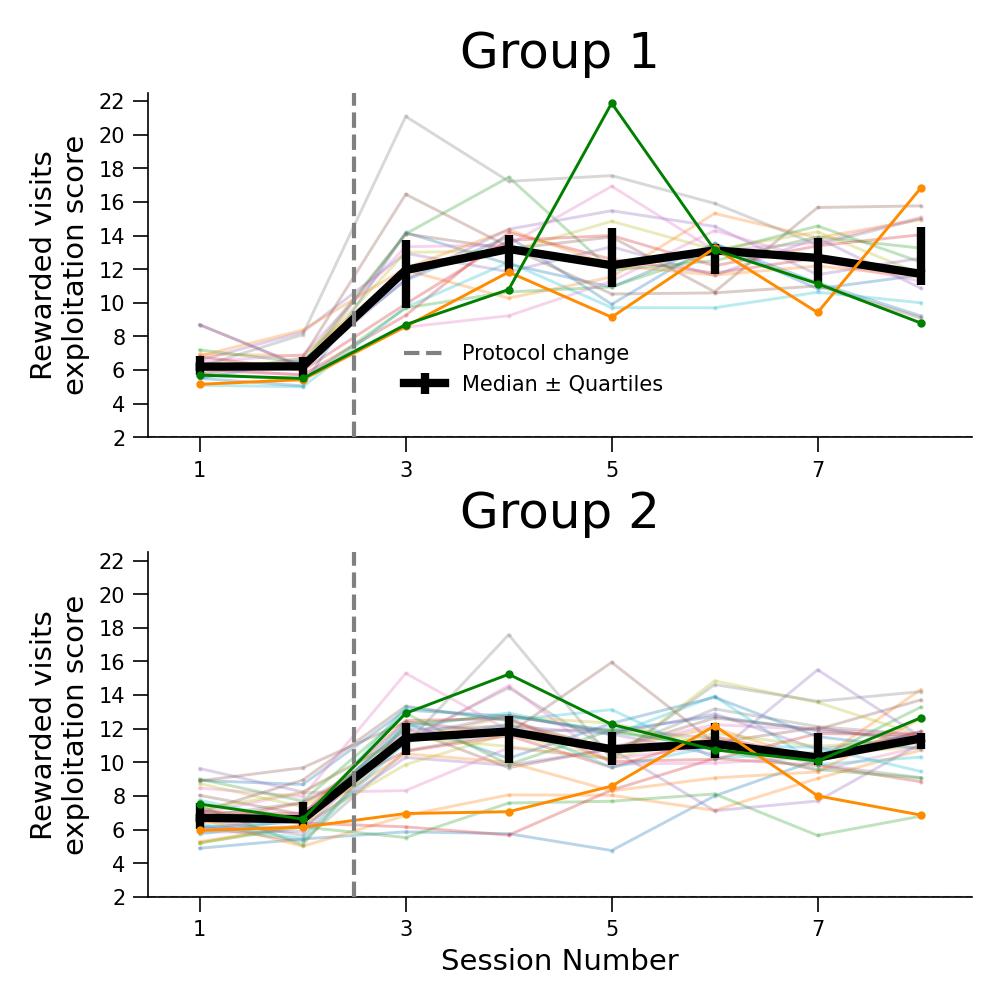

In [11]:
switch_occurence = 2.5

### Panel A ###
fig=plt.figure(figsize=(cm2inch(9), cm2inch(12)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(3, 1 , hspace=0.4, height_ratios=(1,1,0.5))

tick_interval = 2

row1 = gs[0,0].subgridspec(1, 1)
ax_1 = plt.subplot(row1[:])

if switch_occurence:
    ax_1.axvline(switch_occurence, linestyle='--', color='grey', linewidth=1, label="Protocol change", zorder=999)

plot_learning_curves(mouse_mean_turns_per_rewarded_visit_1, ax_1, mice_to_highlight=illustration_mice_1, highlight_colors=illustration_colors,
                     show_individual_mice=True, median_color= 'black', main_line_label='Median \u00B1 Quartiles', show_xlabel = False, xlim=xlim_stats_2, ylim=[2,22.5],
                     ylabel='Rewarded visits\nexploitation score', tick_interval=2, index_offset=0, legend_loc=(0.3,0.1))
ax_1.axhline(2, linestyle='--', color='grey', linewidth=0.5)
ax_1.set_yticks(np.arange(2,23,2))
ax_1.set_title('Group 1')

row2 = gs[1,0].subgridspec(1, 1)
ax_2 = plt.subplot(row2[:])

if switch_occurence:
    ax_2.axvline(switch_occurence, linestyle='--', color='grey', linewidth=1, label="Protocol change", zorder=999)

plot_learning_curves(mouse_mean_turns_per_rewarded_visit_2, ax_2, mice_to_highlight=illustration_mice_2, highlight_colors=illustration_colors,
                     show_individual_mice=True, median_color= 'black', show_xlabel = True, xlim=xlim_stats_2, ylim=[2,22.5],
                     ylabel='Rewarded visits\nexploitation score', tick_interval=2, index_offset=0, show_legend=False)

ax_2.axhline(2, linestyle='--', color='grey', linewidth=0.5)
ax_2.set_title('Group 2')
ax_2.set_yticks(np.arange(2,23,2))

fig.align_ylabels([ax_1,ax_2])

fig.tight_layout()

plt.savefig("FigureS15.png", facecolor='w', 
                edgecolor='none', bbox_inches='tight', format="png", dpi=300)


In [12]:
# Save the figure as a PDF
fig.savefig("FigureS15.pdf", format="pdf", bbox_inches='tight', dpi=300)
